In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**STEP 1: SETTING UP**

In [2]:
#first installing all qiskit libraries we need
#Qiskit Visualisation:- To see the circuit
#Qiskit-Aer :- High performance Simulator
# VERSION - QISKIT 2.X
!pip install qiskit[visualization] qiskit-machine-learning qiskit-aer qiskit-algorithms --quiet
print("Installation is complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
Installation is complete


In [3]:
#The basics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_breast_cancer
#----Classical Machine Learning----
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import pairwise_distances

#----Quantum Computing (ZZFeature Map and ZFeature Map)----
from qiskit.circuit.library import zz_feature_map, z_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


In [4]:
#----CLASSICAL SVM----
#Get Data
data= datasets.load_breast_cancer()
#Visualising Data
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target
#General Knowledge regarding the Breast Cancer Dataset
print("Number of Patients in Dataset:-", df.shape[0])
print("Medical Markers per patient (What was measured):- ", df.shape[1] - 1)
print('~'*54)
print("DIAGNOSIS KEY")
print("0 -> Malignant (Cancerous Tumor)")
print("1 -> Benign (Non-Cancerous")
print('~'*54)
print("Preview of Patient Clinical Table")
display(df.head().style.hide(axis='index'))

Number of Patients in Dataset:- 569
Medical Markers per patient (What was measured):-  30
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DIAGNOSIS KEY
0 -> Malignant (Cancerous Tumor)
1 -> Benign (Non-Cancerous
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Preview of Patient Clinical Table


mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
17.990000,10.380000,122.800000,1001.000000,0.118400,0.277600,0.300100,0.147100,0.241900,0.078710,1.095000,0.905300,8.589000,153.400000,0.006399,0.049040,0.053730,0.015870,0.030030,0.006193,25.380000,17.330000,184.600000,2019.000000,0.162200,0.665600,0.711900,0.265400,0.460100,0.118900,0
20.570000,17.770000,132.900000,1326.000000,0.084740,0.078640,0.086900,0.070170,0.181200,0.056670,0.543500,0.733900,3.398000,74.080000,0.005225,0.013080,0.018600,0.013400,0.013890,0.003532,24.990000,23.410000,158.800000,1956.000000,0.123800,0.186600,0.241600,0.186000,0.275000,0.089020,0
19.690000,21.250000,130.000000,1203.000000,0.109600,0.159900,0.197400,0.127900,0.206900,0.059990,0.745600,0.786900,4.585000,94.030000,0.006150,0.040060,0.038320,0.020580,0.022500,0.004571,23.570000,25.530000,152.500000,1709.000000,0.144400,0.424500,0.450400,0.243000,0.361300,0.087580,0
11.420000,20.380000,77.580000,386.100000,0.142500,0.283900,0.241400,0.105200,0.259700,0.097440,0.495600,1.156000,3.445000,27.230000,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910000,26.500000,98.870000,567.700000,0.209800,0.866300,0.686900,0.257500,0.663800,0.173000,0
20.290000,14.340000,135.100000,1297.000000,0.100300,0.132800,0.198000,0.104300,0.180900,0.058830,0.757200,0.781300,5.438000,94.440000,0.011490,0.024610,0.056880,0.018850,0.017560,0.005115,22.540000,16.670000,152.200000,1575.000000,0.137400,0.205000,0.400000,0.162500,0.236400,0.076780,0


In [5]:
#w/out target column hence the .drop
x = df.drop(['target'], axis=1)
y = df['target']

x_tr_raw, x_te_raw, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42)
print('SIZE OF TRAINING AND TESTING DATASET')
print("Shape of X_train:", x_tr_raw.shape)
print("Shape of X_test:", x_te_raw.shape)

#80% of 569 patients is 455.2 (hence the training shape)

SIZE OF TRAINING AND TESTING DATASET
Shape of X_train: (455, 30)
Shape of X_test: (114, 30)


In [6]:
standard_scaler = StandardScaler()
x_tr_scaled = standard_scaler.fit_transform(x_tr_raw)
x_te_scaled = standard_scaler.transform(x_te_raw)

In [7]:
pca = PCA(n_components=4)
x_tr_pca = pca.fit_transform(x_tr_scaled)
x_te_pca = pca.transform(x_te_scaled)

In [8]:
df_pca = pd.DataFrame(x_tr_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['Target'] = y
print("Sample of PCA-transformed data:")
print(df_pca.head())

Sample of PCA-transformed data:
        PC1       PC2       PC3       PC4  Target
0  4.244903  9.131428  1.504262 -0.650982       0
1  9.053755  0.475310 -3.198215  0.704403       0
2 -2.275374  3.278471  2.816370 -0.268242       0
3 -2.510453  0.743743 -0.736034  2.524633       0
4 -2.302848  2.665155  1.192885 -1.268602       0


In [ ]:
start_time_cl = time.time()
svm = SVC(
    C=10,
    kernel='rbf'
)
svm.fit(x_tr_pca, y_tr)
train_time_cl = time.time() - start_time_cl

In [ ]:
y_pred_cl = svm.predict(x_te_pca)

In [ ]:
print("\nClassification Report:\n", classification_report(y_te, y_pred_cl))

In [9]:
#Preparing everything for the QSVMs
mm_scaler = MinMaxScaler(feature_range=(0, 0.5)).fit(x_tr_pca)
x_tr_q = mm_scaler.transform(x_tr_pca)
x_te_q = mm_scaler.transform(x_te_pca)
print(mm_scaler)

MinMaxScaler(feature_range=(0, 0.5))


In [ ]:
dists = pairwise_distances(x_tr_pca)
print(np.mean(dists), np.std(dists))

# ZZFEATURE MAP

In [10]:
num_qubits = 4
reps = 2
x = ParameterVector('x', length=num_qubits)


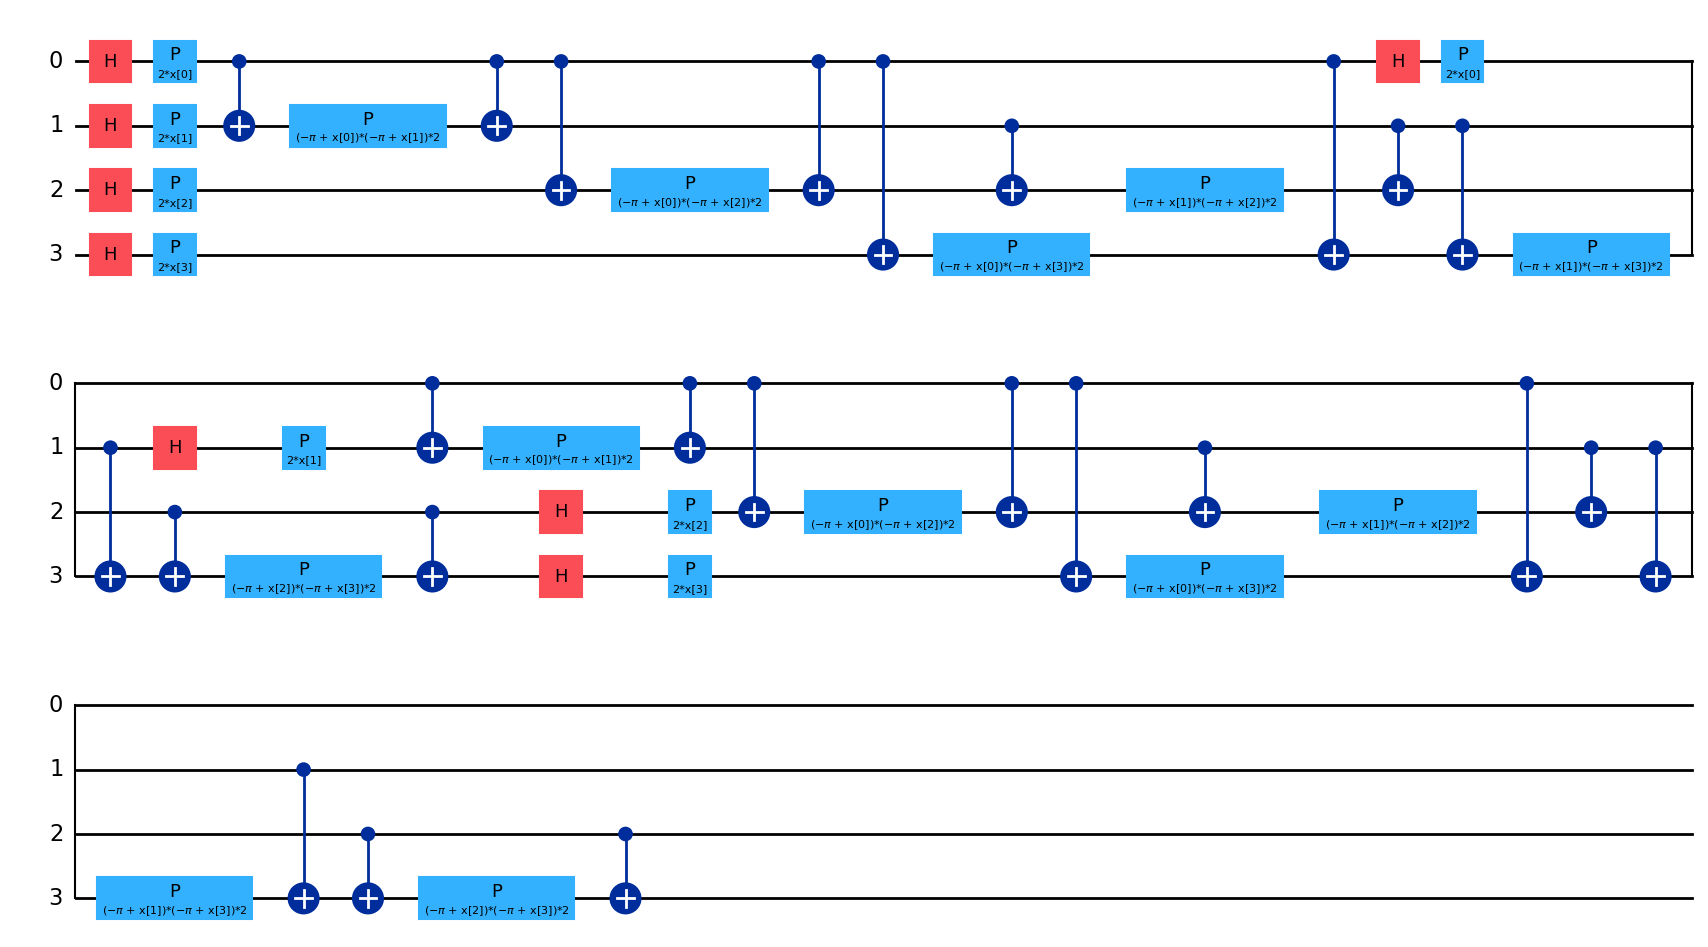

In [13]:
zzfm = zz_feature_map(feature_dimension = num_qubits, reps=reps, entanglement='full')
display(zzfm.draw(output='mpl', style='iqp'))

In [ ]:
sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)
qkernel_zz = FidelityQuantumKernel(fidelity=fidelity, feature_map=zzfm)

In [ ]:
from qiskit_machine_learning.algorithms import QSVC
start = time.perf_counter()
qsvm_zz = QSVC(quantum_kernel=qkernel_zz, C = 10)
qsvm_zz.fit(x_tr_q, y_tr)
end = time.perf_counter()
time_zz = end - start

In [ ]:
y_pred_zz = qsvm_zz.predict(x_te_q)

In [ ]:

accuracy_zz = accuracy_score(y_te, y_pred_zz)
f1_zz = f1_score(y_te, y_pred_zz)
precision_zz = precision_score(y_te, y_pred_zz)
recall_zz = recall_score(y_te, y_pred_zz)
results_zz = {
    "ZZ Quantum Metric": [
        "Accuracy (Precision Total)",
        "F1-Score (Balance)",
        "Sensitivity (Recall)",
        "Training Time (Seconds)"
    ],
    "Result": [
        f"{accuracy_zz*100:.2f}%",
        f"{f1_zz:.4f}",
        f"{recall_zz*100:.2f}%",
        f"{time_zz:.2f}s"
           ]
}
results_df = pd.DataFrame(results_zz)
display(results_df.style.hide(axis='index'))
# 3. Visualizing the Quantum Confusion Matrix
plt.figure(figsize=(7, 5))
cm_zz = confusion_matrix(y_te, y_pred_zz)
sns.heatmap(cm_zz, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Quantum SVM Diagnostic Matrix (ZZ Feature Map)')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Quantum Prediction (ZZ Feature Map')
plt.show()
# 4. Results
print("\n" + "="*50)
print("QSVM Results:")
print(f"The model reached an accuracy of {accuracy_zz*100:.2f}%.")
print(f"Out of {cm_zz[0].sum()} malignant cases, it correctly identified {cm_zz[0,0]}.")
print("="*50)

# ENHANCED ZZ FEATURE MAP

In [ ]:
qc_zze = QuantumCircuit(num_qubits)
#Enhanced ZZfeature Map
#Step 1: Hadamard Gate (Superposition)
for i in range(num_qubits):
    qc_zze.h(i)
qc_zze.barrier()
#Step 2: Encoding
    #1st:- Indivdiually Rotating
for r in range(reps):
    for i in range(num_qubits):
        qc_zze.rz(2 * x[i], i)
    #2nd:- Entanglement (This is what makes the ZZfeature Map different)
    for i in range(num_qubits):
        j = (i + 1) % num_qubits
        qc_zze.cx(i,j)
         #ZZ rotation - CNOT -> RZ -> CNOT
        interaction_term = (np.pi-x[i])*(np.pi - x[j])
        qc_zze.rz(2 * interaction_term, j)
        qc_zze.cx(i,j)
    qc_zze.barrier()
display(qc_zze.draw(output='mpl', style='iqp'))


In [ ]:
#Quantum Kernel
#STEP 1: Setting up the Quantum Fidelity Engine (To see similiarities)
fidelity = ComputeUncompute(sampler=sampler)
qkernel_zze = FidelityQuantumKernel(fidelity=fidelity, feature_map=qc_zze)
start = time.perf_counter()
qsvm_zze = QSVC(quantum_kernel=qkernel_zze, C = 10)
qsvm_zze.fit(x_tr_q, y_tr)
end = time.perf_counter()
time_zze = start - end
y_pred_zze = qsvm_zze.predict(x_te_q)
print(f"Training complete in: {time_zze:.2f} seconds")

In [ ]:
#put in the finding

accuracy_zze = accuracy_score(y_te, y_pred_zze)
f1_zze = f1_score(y_te, y_pred_zze)
precision_zze = precision_score(y_te, y_pred_zze)
recall_zze = recall_score(y_te, y_pred_zze)
results_zze = {
    "ZZ (Modified) Quantum Metric": [
        "Accuracy (Precision Total)",
        "F1-Score (Balance)",
        "Sensitivity (Recall)",
        "Training Time (Seconds)"
    ],
    "Result": [
        f"{accuracy_zze*100:.2f}%",
        f"{f1_zze:.4f}",
        f"{recall_zze*100:.2f}%",
        f"{time_zze:.2f}s"
           ]
}
results_df = pd.DataFrame(results_zze)
display(results_df.style.hide(axis='index'))
# 3. Visualizing the Quantum Confusion Matrix
plt.figure(figsize=(7, 5))
cm_zze= confusion_matrix(y_te, y_pred_zze)
sns.heatmap(cm_zze, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Quantum SVM Diagnostic Matrix (ZZ (modified) Feature Map)')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Quantum Prediction (ZZ Feature Map')
plt.show()
# 4. Results
print("\n" + "="*50)
print("QSVM Results:")
print(f"The model reached an accuracy of {accuracy_zze*100:.2f}%.")
print(f"Out of {cm_zze[0].sum()} malignant cases, it correctly identified {cm_zze[0,0]}.")
print("="*50)

# ZFEATURE MAP


In [ ]:
#implementing feature map
zfm = z_feature_map(feature_dimension = num_qubits, reps = 2 )
display(zfm.draw(output='mpl', style='iqp'))

In [ ]:
fidelity = ComputeUncompute(sampler=sampler)
qkernel_z = FidelityQuantumKernel(fidelity=fidelity, feature_map=zfm)


In [ ]:

start = time.perf_counter()
qsvm_z = QSVC(quantum_kernel=qkernel_z, C = 10)
qsvm_z.fit(x_tr_q, y_tr)
end = time.perf_counter()
time_z = start - end
y_pred_z = qsvm_z.predict(x_te_q)

In [ ]:
accuracy_z = accuracy_score(y_te, y_pred_z)
f1_z = f1_score(y_te, y_pred_z)
precision_z = precision_score(y_te, y_pred_z)
recall_z = recall_score(y_te, y_pred_z)
results_z = {
    "Z Quantum Metric": [
        "Accuracy (Precision Total)",
        "F1-Score (Balance)",
        "Sensitivity (Recall)",
        "Training Time (Seconds)"
    ],
    "Result": [
        f"{accuracy_z*100:.2f}%",
        f"{f1_z:.4f}",
        f"{recall_z*100:.2f}%",
        f"{time_z:.2f}s"
           ]
}
results_df = pd.DataFrame(results_z)
display(results_df.style.hide(axis='index'))
# 3. Visualizing the Quantum Confusion Matrix
plt.figure(figsize=(7, 5))
cm_z= confusion_matrix(y_te, y_pred_z)
sns.heatmap(cm_z, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Quantum SVM Diagnostic Matrix (Z Feature Map)')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Quantum Prediction (Z Feature Map')
plt.show()
# 4. Results
print("\n" + "="*50)
print("QSVM Results:")
print(f"The model reached an accuracy of {accuracy_z*100:.2f}%.")
print(f"Out of {cm_z[0].sum()} malignant cases, it correctly identified {cm_z[0,0]}.")
print("="*50)

# Z FEATURE MAP ENHANCED

main difference is entanglement

In [ ]:
zefm=z_feature_map(feature_dimension = num_qubits, reps = 2, entanglement = 'full')
display(zefm.draw(output='mpl', style='iqp'))

In [ ]:
zefm=z_feature_map(feature_dimension = num_qubits, reps = 2, entanglement = 'full')
fidelity = ComputeUncompute(sampler=sampler)
qkernel_ze = FidelityQuantumKernel(fidelity=fidelity, feature_map=zefm)
start = time.perf_counter()
qsvm_ze = QSVC(quantum_kernel=qkernel_ze, C = 10)
qsvm_ze.fit(x_tr_q, y_tr)
end = time.perf_counter()
time_ze = start - end
y_pred_ze = qsvm_ze.predict(x_te_q)

In [ ]:
accuracy_ze = accuracy_score(y_te, y_pred_ze)
f1_ze = f1_score(y_te, y_pred_ze)
precision_ze = precision_score(y_te, y_pred_ze)
recall_ze = recall_score(y_te, y_pred_ze)
results_ze = {
    "Z (Modified) Quantum Metric": [
        "Accuracy (Precision Total)",
        "F1-Score (Balance)",
        "Sensitivity (Recall)",
        "Training Time (Seconds)"
    ],
    "Result": [
        f"{accuracy_ze*100:.2f}%",
        f"{f1_ze:.4f}",
        f"{recall_ze*100:.2f}%",
        f"{time_ze:.2f}s"
           ]
}
results_df = pd.DataFrame(results_ze)
display(results_df.style.hide(axis='index'))
# 3. Visualizing the Quantum Confusion Matrix
plt.figure(figsize=(7, 5))
cm_ze= confusion_matrix(y_te, y_pred_ze)
sns.heatmap(cm_ze, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Quantum SVM Diagnostic Matrix (Z Feature Map  (Modified))')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Quantum Prediction (Z Feature Map (Modified))')
plt.show()
# 4. Results
print("\n" + "="*50)
print("QSVM Results:")
print(f"The model reached an accuracy of {accuracy_ze*100:.2f}%.")
print(f"Out of {cm_ze[0].sum()} malignant cases, it correctly identified {cm_ze[0,0]}.")
print("="*50)